# ISYE 671: Large-Scale Optimization Methods — Computational Lab

**Northern Illinois University — Spring 2026**  
**Instructor: Dr. Ziteng Wang**

---

This notebook implements the four large-scale methods from the lecture:

1. **Column Generation** — Cutting stock problem & radiation therapy planning
2. **Benders Decomposition** — Emergency supply pre-positioning (stochastic LP)
3. **Lagrangian Relaxation** — Multi-plant production with subgradient optimization

Each method is implemented step-by-step so you can observe the iteration mechanics. We use AMPL/Gurobi for the subproblems and Python for the outer loop logic.

*(Dantzig-Wolfe decomposition is a reformulation solved by column generation — the cutting stock example in Section 1 demonstrates the full DW/CG mechanics.)*

---
## 0. Environment Setup

In [1]:
%pip install amplpy --quiet

from amplpy import AMPL, ampl_notebook

ampl_notebook(
    modules=["gurobi"],
    license_uuid="YOUR-AMPL-LICENSE-UUID"
)

import numpy as np
import matplotlib.pyplot as plt

print("AMPL + Gurobi ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.9 MB/s eta 0:00:00
Licensed to Bundle #7384.7942 expiring 20260531: ISYE 671 linear optimization and network flows, Prof. Ziteng Wang, Northern Illinois University.
AMPL + Gurobi ready.


---
## 1. Column Generation

### 1A. Cutting Stock Problem

A steel mill cuts standard bars of length **W = 100 inches** into requested widths:

| Width | Demand |
|-------|--------|
| 25"   | 40     |
| 30"   | 50     |
| 45"   | 30     |

**Goal**: Minimize the number of standard bars used.

Each feasible **cutting pattern** is a column. We start with simple patterns and iteratively generate improving ones via a **pricing (knapsack) subproblem**.

In [ ]:
%%writefile cutting_master.mod
# Cutting Stock — Restricted Master Problem
# Columns (patterns) are added iteratively

set WIDTHS;
param demand{WIDTHS} >= 0;

param nPatterns >= 1 integer;
set PATTERNS := 1..nPatterns;
param pattern{WIDTHS, PATTERNS} >= 0 integer;

# How many times to use each pattern (LP relaxation)
var x{PATTERNS} >= 0;

minimize total_bars:
    sum{p in PATTERNS} x[p];

subject to meet_demand{w in WIDTHS}:
    sum{p in PATTERNS} pattern[w,p] * x[p] >= demand[w];

Writing cutting_master.mod


In [ ]:
%%writefile cutting_pricing.mod
# Cutting Stock — Pricing Subproblem (Knapsack)
# Find the pattern with the most negative reduced cost

set WIDTHS;
param width{WIDTHS} >= 0;
param dual_value{WIDTHS};
param bar_length >= 0;

var a{WIDTHS} >= 0 integer;

maximize attractiveness:
    sum{w in WIDTHS} dual_value[w] * a[w];

subject to fit_bar:
    sum{w in WIDTHS} width[w] * a[w] <= bar_length;

Writing cutting_pricing.mod


In [ ]:
%%writefile cutting_stock.dat
# Cutting stock problem data

set WIDTHS := W25 W30 W45;

param width :=
    W25  25
    W30  30
    W45  45;

param demand :=
    W25  40
    W30  50
    W45  30;

param bar_length := 100;


Writing cutting_stock.dat


In [ ]:
# Column generation algorithm for cutting stock
# Problem data (matches cutting_stock.dat)
widths = ["W25", "W30", "W45"]
width_val = {"W25": 25, "W30": 30, "W45": 45}
demand_val = {"W25": 40, "W30": 50, "W45": 30}
bar_length = 100

# Small distinct perturbations for RHS to break dual degeneracy
# (standard technique — see Gilmore & Gomory, Lübbecke & Desrosiers)
rhs_perturbation = {w: 1e-6 * (i + 1) for i, w in enumerate(widths)}

# Initial patterns: one dedicated pattern per width
patterns = [
    {"W25": 4, "W30": 0, "W45": 0},
    {"W25": 0, "W30": 3, "W45": 0},
    {"W25": 0, "W30": 0, "W45": 2}
]

iteration_log = []

print("=" * 70)
print("COLUMN GENERATION — CUTTING STOCK")
print("=" * 70)

for iteration in range(20):
    # ---- STEP 1: Solve Restricted Master Problem ----
    # Apply tiny RHS perturbation to break dual degeneracy
    master = AMPL()
    master.option["solver"] = "gurobi"
    master.option["gurobi_options"] = "outlev=0"
    master.read("cutting_master.mod")

    master.set["WIDTHS"] = widths
    perturbed_demand = {w: demand_val[w] + rhs_perturbation[w] for w in widths}
    master.param["demand"] = perturbed_demand
    master.param["nPatterns"] = len(patterns)

    for p_idx, pat in enumerate(patterns):
        for w in widths:
            master.param["pattern"][w, p_idx + 1] = pat[w]

    master.solve()
    obj_val = master.obj["total_bars"].value()

    # Get dual values (now unique due to perturbation)
    duals = {w: master.con["meet_demand"][w].dual() for w in widths}

    # Get pattern usage
    usage = [master.var["x"][p+1].value() for p in range(len(patterns))]

    print(f"\nIteration {iteration + 1}:")
    print(f"  Patterns: {len(patterns)}, Objective (LP): {obj_val:.2f} bars")
    print(f"  Duals: {', '.join(f'{w}={duals[w]:.4f}' for w in widths)}")

    # ---- STEP 2: Solve Pricing Subproblem (Knapsack) ----
    pricing = AMPL()
    pricing.option["solver"] = "gurobi"
    pricing.option["gurobi_options"] = "outlev=0"
    pricing.read("cutting_pricing.mod")

    pricing.set["WIDTHS"] = widths
    pricing.param["width"] = width_val
    pricing.param["dual_value"] = duals
    pricing.param["bar_length"] = bar_length
    pricing.solve()

    attractiveness = pricing.obj["attractiveness"].value()
    reduced_cost = 1.0 - attractiveness

    new_pattern = {w: int(pricing.var["a"][w].value()) for w in widths}

    print(f"  New pattern: {new_pattern}")
    print(f"  Reduced cost: {reduced_cost:.4f}")

    iteration_log.append({
        'iteration': iteration + 1,
        'num_patterns': len(patterns),
        'objective': obj_val,
        'reduced_cost': reduced_cost
    })

    # ---- STEP 3: Check optimality ----
    if reduced_cost >= -1e-6:
        # Solve the master one final time WITHOUT perturbation to get exact objective
        master_final = AMPL()
        master_final.option["solver"] = "gurobi"
        master_final.option["gurobi_options"] = "outlev=0"
        master_final.read("cutting_master.mod")
        master_final.set["WIDTHS"] = widths
        master_final.param["demand"] = demand_val  # original demands
        master_final.param["nPatterns"] = len(patterns)
        for p_idx, pat in enumerate(patterns):
            for w in widths:
                master_final.param["pattern"][w, p_idx + 1] = pat[w]
        master_final.solve()
        obj_final = master_final.obj["total_bars"].value()
        usage = [master_final.var["x"][p+1].value() for p in range(len(patterns))]

        print(f"\n✅ OPTIMAL! No improving pattern exists (reduced cost ≥ 0).")
        print(f"   Optimal LP relaxation: {obj_final:.2f} bars")
        print(f"   Integer solution (round up): {int(np.ceil(obj_final))} bars")
        break

    # ---- STEP 4: Add new pattern ----
    patterns.append(new_pattern)
    print(f"  → Pattern added. Continuing...")

# Display final solution
print(f"\n{'='*70}")
print("FINAL SOLUTION")
print(f"{'='*70}")
print(f"\n{'Pattern':<10} {'W25':>5} {'W30':>5} {'W45':>5} {'Waste':>6} {'Usage':>8}")
print("-" * 45)
for p_idx, pat in enumerate(patterns):
    waste = bar_length - sum(width_val[w] * pat[w] for w in widths)
    u = usage[p_idx] if p_idx < len(usage) else 0
    if u > 0.001:
        print(f"P{p_idx+1:<9} {pat['W25']:>5} {pat['W30']:>5} {pat['W45']:>5} {waste:>5}\" {u:>8.2f}")

COLUMN GENERATION — CUTTING STOCK
Gurobi 13.0.1:   tech:outlev = 0
Gurobi 13.0.1: optimal solution; objective 41.66666908
0 simplex iterations

Iteration 1:
  Patterns: 3, Objective (LP): 41.67 bars
  Duals: W25=0.2500, W30=0.3333, W45=0.5000
Gurobi 13.0.1:   tech:outlev = 0
Gurobi 13.0.1: optimal solution; objective 1.083333333
0 simplex iterations
  New pattern: {'W25': 1, 'W30': 1, 'W45': 1}
  Reduced cost: -0.0833
  → Pattern added. Continuing...
Gurobi 13.0.1:   tech:outlev = 0
Gurobi 13.0.1: optimal solution; objective 39.16666883
4 simplex iterations

Iteration 2:
  Patterns: 4, Objective (LP): 39.17 bars
  Duals: W25=0.2500, W30=0.3333, W45=0.4167
Gurobi 13.0.1:   tech:outlev = 0
Gurobi 13.0.1: optimal solution; objective 1
0 simplex iterations
  New pattern: {'W25': 0, 'W30': 3, 'W45': 0}
  Reduced cost: 0.0000
Gurobi 13.0.1:   tech:outlev = 0
Gurobi 13.0.1: optimal solution; objective 39.16666667
4 simplex iterations

✅ OPTIMAL! No improving pattern exists (reduced cost ≥ 0).

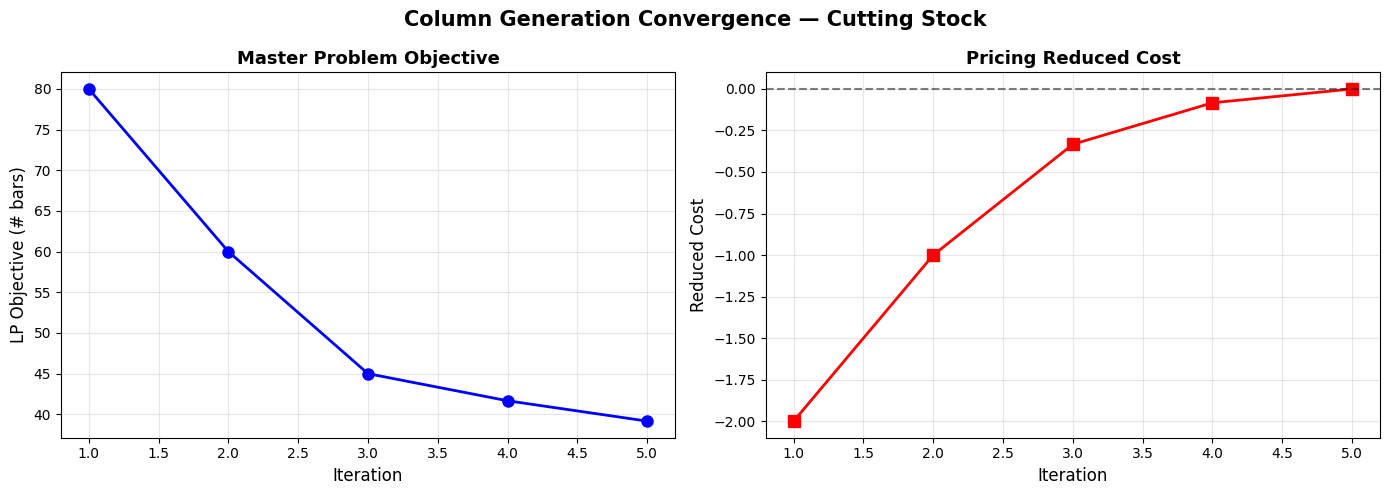

In [ ]:
# Visualize convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters = [r['iteration'] for r in iteration_log]
objs = [r['objective'] for r in iteration_log]
rcs = [r['reduced_cost'] for r in iteration_log]

ax1.plot(iters, objs, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('LP Objective (# bars)', fontsize=12)
ax1.set_title('Master Problem Objective', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(iters, rcs, 'rs-', linewidth=2, markersize=8)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Reduced Cost', fontsize=12)
ax2.set_title('Pricing Reduced Cost', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Column Generation Convergence — Cutting Stock', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 1B. Radiation Therapy Planning (Rardin Application 13.1)

A cancer treatment plan must deliver radiation to a tumor while minimizing dose to healthy tissues. The machine fires beams from 2 angles, each with 9 beamlets. An **aperture** is a subset of beamlets that can be opened simultaneously (subject to physical feasibility rules). Each aperture delivers a known dose pattern.

**Data** (from Rardin Table 13.1):
- 2 beam angles, 9 beamlets each
- 6 tumor points, 6 points in each of 3 healthy tissues (18 healthy points total)
- Dose limits: Healthy 1 ≤ 50, Healthy 2 ≤ 65, Healthy 3 ≤ 70 per point

We use column generation: each **column** is an aperture (a subset of beamlets), and the **pricing subproblem** selects the beamlets that maximize the reduced objective.

In [ ]:
# Rardin Table 13.1 IMRT dose data
# dose_target[angle][beamlet][tumor_point] and dose_healthy[angle][beamlet][tissue][point]

import numpy as np

# Target dose per unit intensity: target[tumor_pt, beamlet] for each angle
target_a1 = np.array([
    [0.100, 0.250, 0.100, 0.080, 0.150, 0.080, 0.050, 0.100, 0.050],  # tumor pt 1
    [0.090, 0.070, 0.050, 0.050, 0.070, 0.090, 0.150, 0.120, 0.100],  # tumor pt 2
    [0.090, 0.070, 0.050, 0.050, 0.070, 0.090, 0.090, 0.080, 0.070],  # tumor pt 3
    [0.100, 0.120, 0.150, 0.090, 0.120, 0.150, 0.090, 0.070, 0.050],  # tumor pt 4
    [0.090, 0.080, 0.110, 0.080, 0.070, 0.130, 0.090, 0.070, 0.050],  # tumor pt 5
    [0.050, 0.100, 0.050, 0.070, 0.120, 0.090, 0.100, 0.250, 0.100],  # tumor pt 6
])

target_a2 = np.array([
    [0.100, 0.250, 0.100, 0.080, 0.150, 0.080, 0.050, 0.100, 0.050],
    [0.100, 0.120, 0.150, 0.090, 0.120, 0.150, 0.090, 0.070, 0.050],
    [0.090, 0.080, 0.110, 0.080, 0.070, 0.130, 0.090, 0.070, 0.050],
    [0.090, 0.070, 0.050, 0.050, 0.070, 0.090, 0.150, 0.120, 0.100],
    [0.090, 0.070, 0.050, 0.050, 0.070, 0.090, 0.090, 0.080, 0.070],
    [0.050, 0.100, 0.050, 0.070, 0.120, 0.090, 0.100, 0.250, 0.100],
])

# Healthy tissue dose: h1_a1[point, beamlet], etc.
h1_a1 = np.array([
    [0.150,0.375,0.150,0.120,0.225,0.120,0.075,0.150,0.075],
    [0.135,0.105,0.075,0.075,0.105,0.135,0.225,0.180,0.150],
    [0.135,0.105,0.075,0.075,0.105,0.135,0.135,0.120,0.105],
    [0.150,0.180,0.225,0.135,0.180,0.225,0.135,0.105,0.075],
    [0.135,0.120,0.165,0.120,0.105,0.195,0.135,0.105,0.075],
    [0.075,0.150,0.075,0.105,0.180,0.135,0.150,0.375,0.150],
])
h2_a1 = np.array([
    [0.070,0.100,0.075,0.042,0.060,0.042,0.060,0.040,0.028],
    [0.020,0.028,0.068,0.020,0.028,0.020,0.038,0.048,0.034],
    [0.020,0.028,0.068,0.020,0.028,0.020,0.038,0.032,0.022],
    [0.034,0.048,0.075,0.034,0.048,0.034,0.068,0.028,0.020],
    [0.022,0.032,0.068,0.020,0.028,0.020,0.060,0.028,0.020],
    [0.028,0.040,0.038,0.034,0.048,0.034,0.053,0.100,0.070],
])
h3_a1 = np.array([
    [0.090,0.225,0.090,0.072,0.135,0.072,0.045,0.090,0.045],
    [0.081,0.063,0.045,0.045,0.063,0.081,0.135,0.108,0.090],
    [0.081,0.063,0.045,0.045,0.063,0.081,0.081,0.072,0.063],
    [0.090,0.108,0.135,0.081,0.108,0.135,0.081,0.063,0.045],
    [0.081,0.072,0.099,0.072,0.063,0.117,0.081,0.063,0.045],
    [0.045,0.090,0.045,0.063,0.108,0.081,0.090,0.225,0.090],
])
h1_a2 = np.array([
    [0.075,0.100,0.070,0.060,0.060,0.042,0.038,0.040,0.028],
    [0.068,0.028,0.020,0.038,0.028,0.020,0.113,0.048,0.034],
    [0.068,0.028,0.020,0.038,0.028,0.020,0.068,0.032,0.022],
    [0.075,0.048,0.034,0.068,0.048,0.034,0.068,0.028,0.020],
    [0.068,0.032,0.022,0.060,0.028,0.020,0.068,0.028,0.020],
    [0.038,0.040,0.028,0.053,0.048,0.034,0.075,0.100,0.070],
])
h2_a2 = np.array([
    [0.150,0.375,0.150,0.120,0.225,0.120,0.075,0.150,0.075],
    [0.150,0.180,0.225,0.135,0.180,0.225,0.135,0.105,0.075],
    [0.135,0.120,0.165,0.120,0.105,0.195,0.135,0.105,0.075],
    [0.135,0.105,0.075,0.075,0.105,0.135,0.225,0.180,0.150],
    [0.135,0.105,0.075,0.075,0.105,0.135,0.135,0.120,0.105],
    [0.075,0.150,0.075,0.105,0.180,0.135,0.150,0.375,0.150],
])
h3_a2 = np.array([
    [0.090,0.225,0.090,0.072,0.135,0.072,0.045,0.090,0.045],
    [0.090,0.108,0.135,0.081,0.108,0.135,0.081,0.063,0.045],
    [0.081,0.072,0.099,0.072,0.063,0.117,0.081,0.063,0.045],
    [0.081,0.063,0.045,0.045,0.063,0.081,0.135,0.108,0.090],
    [0.081,0.063,0.045,0.045,0.063,0.081,0.081,0.072,0.063],
    [0.045,0.090,0.045,0.063,0.108,0.081,0.090,0.225,0.090],
])

# Dose limits per point for each healthy tissue
b_limits = {1: 50, 2: 65, 3: 70}  # per Rardin
n_beamlets = 9
n_tumor_pts = 6
n_healthy_pts = 6  # per tissue
n_angles = 2

# Pack into convenient structures
# target_dose[angle][beamlet] = sum of tumor doses across all tumor points
# healthy_dose[angle][tissue][point][beamlet]
target = [target_a1, target_a2]
healthy = [[h1_a1, h2_a1, h3_a1], [h1_a2, h2_a2, h3_a2]]

def compute_aperture(angle, beamlet_set):
    """Compute aggregated dose coefficients for an aperture (subset of beamlets)."""
    t_dose = target[angle][:, beamlet_set].sum(axis=1)  # per tumor point
    t_total = t_dose.sum()  # total target dose
    h_doses = {}  # {tissue: array of dose per point}
    for tissue in range(3):
        h_doses[tissue] = healthy[angle][tissue][:, beamlet_set].sum(axis=1)
    return t_total, t_dose, h_doses

print(f"IMRT data loaded from Rardin Table 13.1")
print(f"  {n_angles} angles × {n_beamlets} beamlets = {n_angles * n_beamlets} total beamlets")
print(f"  {n_tumor_pts} tumor points, {n_healthy_pts} points × 3 healthy tissues")
print(f"  Dose limits: H1≤{b_limits[1]}, H2≤{b_limits[2]}, H3≤{b_limits[3]}")

# Verify Rardin's initial aperture (all beamlets open)
t1, _, _ = compute_aperture(0, list(range(9)))
t2, _, _ = compute_aperture(1, list(range(9)))
print(f"\nVerification (Rardin Table 13.2):")
print(f"  Aperture A1,1 (all beamlets, angle 1): total target = {t1:.3f} (expect 5.050)")
print(f"  Aperture A2,1 (all beamlets, angle 2): total target = {t2:.3f} (expect 5.050)")

In [ ]:
# Column generation for IMRT using Rardin data
# Each column = an aperture (angle, subset of beamlets)
# Master: max total tumor dose subject to healthy tissue limits
# Pricing: for each angle, find the beamlet subset with most positive reduced obj

# Apertures stored as (angle, beamlet_list, t_total, h_doses_dict)
apertures = []

# Initial apertures: all beamlets open for each angle (Rardin's starting point)
for angle in range(n_angles):
    bl = list(range(n_beamlets))
    t_total, t_dose, h_doses = compute_aperture(angle, bl)
    apertures.append({'angle': angle, 'beamlets': bl, 't_total': t_total,
                      't_dose': t_dose, 'h_doses': h_doses})

rt_log = []

print("=" * 75)
print("COLUMN GENERATION — IMRT RADIATION THERAPY (Rardin Application 13.1)")
print("=" * 75)

for iteration in range(20):
    n_ap = len(apertures)

    # ---- Build and solve RMP ----
    rmp = AMPL()
    rmp.option["solver"] = "gurobi"
    rmp.option["gurobi_options"] = "outlev=0"

    # Build model programmatically
    rmp.eval(f"param nAp := {n_ap};")
    rmp.eval("set APS := 1..nAp;")
    rmp.eval(f"param nPts := {n_healthy_pts};")
    rmp.eval("set PTS := 1..nPts;")
    rmp.eval("set TISSUES := 1..3;")
    rmp.eval("param t_total{APS};")
    rmp.eval("param h_dose{TISSUES, PTS, APS};")
    rmp.eval("param b_lim{TISSUES};")
    rmp.eval("var x{APS} >= 0;")
    rmp.eval("maximize total_tumor: sum{a in APS} t_total[a] * x[a];")
    rmp.eval("subject to healthy_limit{t in TISSUES, p in PTS}: "
             "sum{a in APS} h_dose[t,p,a] * x[a] <= b_lim[t];")

    for j, ap in enumerate(apertures):
        rmp.param["t_total"][j+1] = ap['t_total']
        for tissue in range(3):
            for pt in range(n_healthy_pts):
                rmp.param["h_dose"][tissue+1, pt+1, j+1] = float(ap['h_doses'][tissue][pt])
    for tissue in range(3):
        rmp.param["b_lim"][tissue+1] = b_limits[tissue+1]

    rmp.solve()
    obj_val = rmp.obj["total_tumor"].value()

    # Get duals on healthy tissue constraints
    duals = {}  # (tissue, point) -> dual value
    for tissue in range(3):
        for pt in range(n_healthy_pts):
            duals[(tissue, pt)] = rmp.con["healthy_limit"][tissue+1, pt+1].dual()

    # Get active apertures
    active = sum(1 for j in range(n_ap) if rmp.var["x"][j+1].value() > 0.01)

    # ---- Pricing: for each angle, find best new aperture ----
    best_rc = 0
    best_aperture = None

    for angle in range(n_angles):
        # Compute mini-reduced objective for each beamlet
        mini_rc = np.zeros(n_beamlets)
        for q in range(n_beamlets):
            # Contribution to tumor objective
            tumor_contrib = target[angle][:, q].sum()
            # Dual penalty for healthy tissue dose
            dual_penalty = 0
            for tissue in range(3):
                for pt in range(n_healthy_pts):
                    dual_penalty += duals[(tissue, pt)] * healthy[angle][tissue][pt, q]
            mini_rc[q] = tumor_contrib - dual_penalty  # Note: dual_penalty has correct sign for max

        # Select beamlets with positive mini-reduced cost (greedy heuristic)
        # Sort by mini_rc descending, add beamlets that improve total
        sorted_beamlets = np.argsort(-mini_rc)
        selected = []
        for q in sorted_beamlets:
            if mini_rc[q] > 0:
                selected.append(int(q))

        if not selected:
            continue

        # Compute reduced cost of this aperture
        t_total, t_dose, h_doses = compute_aperture(angle, selected)
        rc = t_total  # objective coefficient
        for tissue in range(3):
            for pt in range(n_healthy_pts):
                rc -= duals[(tissue, pt)] * h_doses[tissue][pt]

        if rc > best_rc + 1e-6:
            best_rc = rc
            best_aperture = {'angle': angle, 'beamlets': selected,
                            't_total': t_total, 't_dose': t_dose, 'h_doses': h_doses}

    rt_log.append({'iteration': iteration+1, 'n_apertures': n_ap,
                   'active': active, 'objective': obj_val, 'best_rc': best_rc})

    print(f"Iter {iteration+1:>2}: apertures={n_ap:>3}, active={active:>2}, "
          f"tumor dose={obj_val:>8.2f}, best RC={best_rc:>8.4f}")

    if best_aperture is None or best_rc < 1e-4:
        print(f"\n✅ OPTIMAL! No improving aperture exists.")
        print(f"   Total tumor dose: {obj_val:.2f}")
        print(f"   Apertures used: {active} out of {n_ap} generated")
        print(f"   Iterations: {iteration + 1}")
        # Show active apertures
        print(f"\nActive apertures:")
        print(f"{'#':>3} {'Angle':>6} {'Beamlets':<25} {'Intensity':>10} {'Tumor':>8}")
        print("-" * 56)
        for j, ap in enumerate(apertures):
            inten = rmp.var["x"][j+1].value()
            if inten > 0.01:
                bl_str = ','.join(str(b+1) for b in ap['beamlets'])
                print(f"{j+1:>3} {ap['angle']+1:>6} {bl_str:<25} {inten:>10.2f} {ap['t_total']:>8.3f}")
        break

    apertures.append(best_aperture)


In [ ]:
# Visualize IMRT CG convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters_rt = [r['iteration'] for r in rt_log]
objs_rt = [r['objective'] for r in rt_log]
active_rt = [r['active'] for r in rt_log]

ax1.plot(iters_rt, objs_rt, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Total Tumor Dose (maximize)', fontsize=12)
ax1.set_title('Master Objective', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(iters_rt, active_rt, 'g^-', linewidth=2, markersize=7)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Active Apertures in Plan', fontsize=12)
ax2.set_title('Aperture Selection', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Column Generation — IMRT Planning (Rardin App 13.1)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"💡 Column generation found the optimal treatment plan using {active_rt[-1]} apertures.")
print(f"   Each iteration generates a new aperture by selecting beamlets with")
print(f"   positive mini-reduced objectives — the same approach as Rardin Table 13.3.")

---
## 1C. Dantzig-Wolfe Decomposition: Multi-Factory Production

*(Lecture Notes Section 3.6)*

A company operates **3 factories**, each producing two products (A and B) with its own costs, machine hours, and labor limits. All factories ship to a **shared warehouse** with limited storage.

**Block structure:**
- Each factory has its own constraints (capacity, labor, machine hours) — these are the **block constraints** (many rows).
- The shared warehouse capacity is the **linking constraint** (few rows).

**DW reformulation**: Instead of keeping all factory constraints in the master, we represent each factory's feasible region by its extreme points. The master only has the warehouse linking constraints + one convexity constraint per factory.

**Original**: 2 linking + ~18 block rows = 20 rows.  
**After DW**: 2 linking + 3 convexity = 5 rows (but many columns).

We solve the DW master using column generation, where each pricing subproblem is a single factory's LP.

In [ ]:
%%writefile factory_monolithic.mod
# Multi-Factory Production — Original (all-in-one) formulation
# 3 factories, 2 products, shared warehouse

set FACTORIES;
set PRODUCTS;

param cost{FACTORIES, PRODUCTS} >= 0;       # Production cost per unit
param machine{FACTORIES, PRODUCTS} >= 0;     # Machine hours per unit
param labor{FACTORIES, PRODUCTS} >= 0;       # Labor hours per unit
param machine_cap{FACTORIES} >= 0;           # Machine capacity
param labor_cap{FACTORIES} >= 0;             # Labor capacity
param prod_cap{FACTORIES, PRODUCTS} >= 0;    # Max production per product
param warehouse_cap{PRODUCTS} >= 0;          # Shared warehouse capacity per product
param min_total{PRODUCTS} >= 0;              # Minimum total production

var x{FACTORIES, PRODUCTS} >= 0;

minimize total_cost:
    sum{f in FACTORIES, p in PRODUCTS} cost[f,p] * x[f,p];

# Linking: shared warehouse capacity
subject to warehouse{p in PRODUCTS}:
    sum{f in FACTORIES} x[f,p] <= warehouse_cap[p];

# Linking: minimum total production
subject to min_prod{p in PRODUCTS}:
    sum{f in FACTORIES} x[f,p] >= min_total[p];

# Block: factory machine capacity
subject to machine_limit{f in FACTORIES}:
    sum{p in PRODUCTS} machine[f,p] * x[f,p] <= machine_cap[f];

# Block: factory labor capacity
subject to labor_limit{f in FACTORIES}:
    sum{p in PRODUCTS} labor[f,p] * x[f,p] <= labor_cap[f];

# Block: per-product upper bounds
subject to prod_upper{f in FACTORIES, p in PRODUCTS}:
    x[f,p] <= prod_cap[f,p];

In [ ]:
%%writefile factory.dat
set FACTORIES := F1 F2 F3;
set PRODUCTS := A B C;

# Production cost ($/unit) — asymmetric specialization
param cost:
       A    B    C :=
F1     8   20   14
F2    18    7   16
F3    15   15    6;

# Machine hours per unit
param machine:
       A    B    C :=
F1    2.0  3.5  2.5
F2    3.0  1.5  3.0
F3    2.5  2.5  1.5;

# Labor hours per unit
param labor:
       A    B    C :=
F1    3.0  1.5  2.0
F2    1.5  3.0  2.5
F3    2.0  2.0  3.5;

param machine_cap := F1 400  F2 380  F3 420;
param labor_cap :=   F1 450  F2 400  F3 400;

param prod_cap:
       A     B     C :=
F1   100    80    70
F2    70    90    60
F3    80    70   100;

# Shared warehouse capacity and minimum production (linking constraints)
param warehouse_cap := A 180  B 170  C 160;
param min_total :=     A 100  B  90  C  80;


In [ ]:
# Solve the original (all-in-one) formulation for comparison
mono = AMPL()
mono.option["solver"] = "gurobi"
mono.option["gurobi_options"] = "outlev=0"
mono.read("factory_monolithic.mod")
mono.readData("factory.dat")
mono.solve()

mono_obj = mono.obj["total_cost"].value()
factories = list(mono.set["FACTORIES"].members())
products = list(mono.set["PRODUCTS"].members())

print(f"Original formulation optimal cost: ${mono_obj:,.2f}")
print(f"\n{'Factory':<10}", end="")
for p in products:
    print(f" {p:>8}", end="")
print()
print("-" * 28)
for f in factories:
    print(f"{f:<10}", end="")
    for p in products:
        print(f" {mono.var['x'][f,p].value():>8.1f}", end="")
    print()

# Count constraints
n_linking = len(products) * 2  # warehouse + min_prod
n_block = len(factories) * (2 + len(products))  # machine + labor + prod_cap
print(f"\nConstraints: {n_linking} linking + {n_block} block = {n_linking + n_block} total")
print(f"After DW: {n_linking} linking + {len(factories)} convexity = {n_linking + len(factories)} rows")

In [ ]:
%%writefile dw_master.mod
# Dantzig-Wolfe Master Problem
# Variables are weights on extreme points of each factory's feasible region

set FACTORIES;
set PRODUCTS;

param nColumns{FACTORIES} >= 0 integer;     # Number of columns per factory
param col_cost{f in FACTORIES, 1..nColumns[f]} >= 0;         # Cost of each column
param col_prod{f in FACTORIES, PRODUCTS, 1..nColumns[f]} >= 0; # Production in each column

param warehouse_cap{PRODUCTS} >= 0;
param min_total{PRODUCTS} >= 0;

# Weight on each column (extreme point)
var lambda{f in FACTORIES, j in 1..nColumns[f]} >= 0;

minimize master_cost:
    sum{f in FACTORIES, j in 1..nColumns[f]} col_cost[f,j] * lambda[f,j];

# Linking: warehouse capacity
subject to warehouse{p in PRODUCTS}:
    sum{f in FACTORIES, j in 1..nColumns[f]} col_prod[f,p,j] * lambda[f,j] <= warehouse_cap[p];

# Linking: minimum production
subject to min_prod{p in PRODUCTS}:
    sum{f in FACTORIES, j in 1..nColumns[f]} col_prod[f,p,j] * lambda[f,j] >= min_total[p];

# Convexity: one per factory
subject to convexity{f in FACTORIES}:
    sum{j in 1..nColumns[f]} lambda[f,j] = 1;

In [ ]:
%%writefile dw_pricing.mod
# DW Pricing Subproblem for one factory
# Optimize over the factory's feasible region with modified costs

set PRODUCTS;

param mod_cost{PRODUCTS};                 # Modified cost = original - pi' * A_k
param machine_rate{PRODUCTS} >= 0;
param labor_rate{PRODUCTS} >= 0;
param machine_cap >= 0;
param labor_cap >= 0;
param prod_cap{PRODUCTS} >= 0;

var x{p in PRODUCTS} >= 0, <= prod_cap[p];

minimize pricing_cost:
    sum{p in PRODUCTS} mod_cost[p] * x[p];

subject to machine_limit:
    sum{p in PRODUCTS} machine_rate[p] * x[p] <= machine_cap;

subject to labor_limit:
    sum{p in PRODUCTS} labor_rate[p] * x[p] <= labor_cap;

In [ ]:
# Dantzig-Wolfe decomposition via column generation
# Load problem data from factory.dat
_dw = AMPL()
_dw.read("factory_monolithic.mod")
_dw.readData("factory.dat")
factories = list(_dw.set["FACTORIES"].members())
products = list(_dw.set["PRODUCTS"].members())

# Extract data into Python dicts for the CG loop
factory_data = {}
for f in factories:
    factory_data[f] = {
        "cost": {p: _dw.param["cost"][f,p] for p in products},
        "machine": {p: _dw.param["machine"][f,p] for p in products},
        "labor": {p: _dw.param["labor"][f,p] for p in products},
        "machine_cap": _dw.param["machine_cap"][f],
        "labor_cap": _dw.param["labor_cap"][f],
        "prod_cap": {p: _dw.param["prod_cap"][f,p] for p in products}
    }
wh_cap = {p: _dw.param["warehouse_cap"][p] for p in products}
min_tot = {p: _dw.param["min_total"][p] for p in products}
print(f"Loaded: {len(factories)} factories, {len(products)} products")
print(f"Warehouse caps: {wh_cap}")
print(f"Min production: {min_tot}")

# Initial columns: produce nothing + solve each factory's LP for a feasible plan
# (Important: initial columns must be FEASIBLE extreme points of each factory's polyhedron)
columns = {f: [] for f in factories}
for f in factories:
    # Column 0: produce nothing (always feasible, cost=0)
    columns[f].append({p: 0 for p in products})
    columns[f][-1]["cost"] = 0

    # Column 1: solve the factory LP to find a feasible production plan
    # This ensures the column respects machine/labor constraints
    fd = factory_data[f]
    init_sub = AMPL()
    init_sub.option["solver"] = "gurobi"
    init_sub.option["gurobi_options"] = "outlev=0"
    init_sub.read("dw_pricing.mod")
    init_sub.set["PRODUCTS"] = products
    for p in products:
        init_sub.param["mod_cost"][p] = fd["cost"][p]  # Use original costs
        init_sub.param["machine_rate"][p] = fd["machine"][p]
        init_sub.param["labor_rate"][p] = fd["labor"][p]
        init_sub.param["prod_cap"][p] = fd["prod_cap"][p]
    init_sub.param["machine_cap"] = fd["machine_cap"]
    init_sub.param["labor_cap"] = fd["labor_cap"]
    init_sub.solve()
    col = {}
    orig_cost = 0
    for p in products:
        val = init_sub.var["x"][p].value()
        col[p] = val
        orig_cost += fd["cost"][p] * val
    col["cost"] = orig_cost
    columns[f].append(col)
    print(f"  {f} initial plan: " + ", ".join(f"{p}={col[p]:.0f}" for p in products))

dw_log = []

print("=" * 75)
print("DANTZIG-WOLFE DECOMPOSITION — MULTI-FACTORY PRODUCTION")
print("=" * 75)

for iteration in range(25):
    # ---- Solve DW Master ----
    m = AMPL()
    m.option["solver"] = "gurobi"
    m.option["gurobi_options"] = "outlev=0"
    m.read("dw_master.mod")
    m.set["FACTORIES"] = factories
    m.set["PRODUCTS"] = products
    m.param["warehouse_cap"] = wh_cap
    m.param["min_total"] = min_tot

    for f in factories:
        m.param["nColumns"][f] = len(columns[f])
        for j, col in enumerate(columns[f]):
            m.param["col_cost"][f, j+1] = col["cost"]
            for p in products:
                m.param["col_prod"][f, p, j+1] = col[p]

    m.solve()

    if m.solve_result != "solved":
        print(f"Iter {iteration+1}: Master infeasible — adding more columns")
        for f in factories:
            fd = factory_data[f]
            col = {p: fd["prod_cap"][p] for p in products}
            col["cost"] = sum(fd["cost"][p] * col[p] for p in products)
            columns[f].append(col)
        continue

    master_obj = m.obj["master_cost"].value()
    pi_wh = {p: m.con["warehouse"][p].dual() for p in products}
    pi_min = {p: m.con["min_prod"][p].dual() for p in products}
    sigma = {f: m.con["convexity"][f].dual() for f in factories}

    # ---- Pricing: one subproblem per factory ----
    any_added = False
    best_rc = 0

    for f in factories:
        fd = factory_data[f]
        sub = AMPL()
        sub.option["solver"] = "gurobi"
        sub.option["gurobi_options"] = "outlev=0"
        sub.read("dw_pricing.mod")
        sub.set["PRODUCTS"] = products
        for p in products:
            sub.param["mod_cost"][p] = fd["cost"][p] - pi_wh[p] - pi_min[p]
            sub.param["machine_rate"][p] = fd["machine"][p]
            sub.param["labor_rate"][p] = fd["labor"][p]
            sub.param["prod_cap"][p] = fd["prod_cap"][p]
        sub.param["machine_cap"] = fd["machine_cap"]
        sub.param["labor_cap"] = fd["labor_cap"]
        sub.solve()

        pricing_obj = sub.obj["pricing_cost"].value()
        rc = pricing_obj - sigma[f]
        if rc < best_rc:
            best_rc = rc

        if rc < -1e-6:
            new_col = {}
            orig_cost = 0
            for p in products:
                val = sub.var["x"][p].value()
                new_col[p] = val
                orig_cost += fd["cost"][p] * val
            new_col["cost"] = orig_cost
            columns[f].append(new_col)
            any_added = True

    total_cols = sum(len(columns[f]) for f in factories)
    dw_log.append({'iteration': iteration+1, 'objective': master_obj,
                   'best_rc': best_rc, 'total_cols': total_cols})
    print(f"Iter {iteration+1:>2}: obj=${master_obj:>10,.2f}  best_rc={best_rc:>9.4f}  cols={total_cols}")

    if not any_added:
        print(f"\n✅ OPTIMAL! No improving column from any factory.")
        print(f"   DW optimal cost:     ${master_obj:,.2f}")
        print(f"   Original formulation: ${mono_obj:,.2f}")
        match = abs(master_obj - mono_obj) < 0.01
        print(f"   Match: {'✓ Yes' if match else '✗ No — check formulation'}")
        print(f"   Columns generated: {total_cols}")
        print(f"   Master rows: {len(products)*2 + len(factories)} "
              f"(vs {n_linking + n_block} in original)")
        # Recover production plan
        print(f"\nRecovered production plan:")
        print(f"{'Factory':<10}", end="")
        for p in products:
            print(f" {p:>8}", end="")
        print()
        print("-" * 36)
        for f in factories:
            x_rec = {p: 0 for p in products}
            for j, col in enumerate(columns[f]):
                lam = m.var["lambda"][f, j+1].value()
                if lam > 1e-6:
                    for p in products:
                        x_rec[p] += lam * col[p]
            print(f"{f:<10}", end="")
            for p in products:
                print(f" {x_rec[p]:>8.1f}", end="")
            print()
        break


In [ ]:
# Visualize DW convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters_dw = [r['iteration'] for r in dw_log]
objs_dw = [r['objective'] for r in dw_log]
cols_dw = [r['total_cols'] for r in dw_log]

ax1.plot(iters_dw, objs_dw, 'bo-', linewidth=2, markersize=7)
ax1.axhline(y=mono_obj, color='green', linestyle='--', linewidth=2,
            label=f'Original formulation (${mono_obj:,.0f})')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Master Objective ($)', fontsize=12)
ax1.set_title('DW Master Objective', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(iters_dw, cols_dw, 'rs-', linewidth=2, markersize=7)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Total Columns', fontsize=12)
ax2.set_title('Columns Generated', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Dantzig-Wolfe Decomposition — Multi-Factory Production',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 DW reduced the master from {n_linking + n_block} rows to {len(products)*2 + len(factories)} rows.")
print(f"   Each iteration generates up to {len(factories)} new columns (one per factory).")
print(f"   The pricing subproblem for each factory is a small LP with its own constraints.")
print(f"   The master never sees factory-internal constraints — only their production outputs.")


---
## 3. Benders Decomposition: Emergency Supply Pre-Positioning

We decompose the emergency supply stochastic LP (from the Optimization under Uncertainty lab). A relief agency pre-positions kits at 3 warehouses (first stage) before hurricane season, then ships to affected zones (second stage) across 4 scenarios.

The **master** chooses pre-positioning quantities (complicating variables). The **subproblems** (one per scenario) compute optimal shipping/shortfall/salvage and generate **optimality cuts**.

This problem has 3 first-stage variables, 4 scenarios with different demand patterns, and 15 second-stage variables per scenario — enough structure that Benders requires multiple iterations.

In [ ]:
%%writefile benders_master.mod
# Benders Master — Emergency Supply Pre-Positioning

set WAREHOUSES;
set SCENARIOS;
param prob{SCENARIOS} >= 0;
param preposition_cost := 200;
param warehouse_cap{WAREHOUSES} >= 0;

param nCuts >= 0 integer default 0;
set CUTS := 1..nCuts;

param alpha{SCENARIOS, CUTS} default 0;
param beta{SCENARIOS, CUTS, WAREHOUSES} default 0;

var prepos{w in WAREHOUSES} >= 0, <= warehouse_cap[w];
var theta{SCENARIOS} >= -1e7;

minimize master_obj:
    sum{w in WAREHOUSES} preposition_cost * prepos[w]
    + sum{s in SCENARIOS} prob[s] * theta[s];

subject to benders_cut{s in SCENARIOS, k in CUTS}:
    theta[s] >= alpha[s,k] + sum{w in WAREHOUSES} beta[s,k,w] * prepos[w];

In [ ]:
%%writefile benders_sub.mod
# Benders Subproblem — one scenario

set WAREHOUSES;
set ZONES;

param prepos_fixed{WAREHOUSES} >= 0;
param ship_cost{WAREHOUSES, ZONES} >= 0;
param demand_s{ZONES} >= 0;
param penalty := 500;
param salvage := 50;

var ship{WAREHOUSES, ZONES} >= 0;
var shortfall{ZONES} >= 0;
var unused{WAREHOUSES} >= 0;

minimize sub_cost:
    sum{w in WAREHOUSES, z in ZONES} ship_cost[w,z] * ship[w,z]
    + penalty * sum{z in ZONES} shortfall[z]
    - salvage * sum{w in WAREHOUSES} unused[w];

subject to warehouse_bal{w in WAREHOUSES}:
    sum{z in ZONES} ship[w,z] + unused[w] = prepos_fixed[w];

subject to zone_dem{z in ZONES}:
    sum{w in WAREHOUSES} ship[w,z] + shortfall[z] = demand_s[z];

In [ ]:
%%writefile emergency_benders.dat
# Emergency supply pre-positioning — Benders data

set WAREHOUSES := W1 W2 W3;
set ZONES := ZoneA ZoneB ZoneC;
set SCENARIOS := Cat1 Cat3 Cat5 None;

param prob :=
    Cat1 0.40  Cat3 0.35  Cat5 0.15  None 0.10;

param warehouse_cap :=
    W1 500  W2 500  W3 500;

param ship_cost:
        ZoneA  ZoneB  ZoneC :=
W1        20     40     60
W2        50     15     35
W3        45     30     10;

param demand:
          Cat1  Cat3  Cat5  None :=
ZoneA      100   300   500    0
ZoneB       80   200   400    0
ZoneC       50   150   350    0;


In [ ]:
# Benders decomposition algorithm
# Load problem data from .dat file using a dedicated loader
_bd = AMPL()
_bd.eval('''
    set WAREHOUSES;
    set ZONES;
    set SCENARIOS;
    param prob{SCENARIOS} >= 0;
    param warehouse_cap{WAREHOUSES} >= 0;
    param ship_cost{WAREHOUSES, ZONES} >= 0;
    param demand{ZONES, SCENARIOS} >= 0;
''')
_bd.readData("emergency_benders.dat")
warehouses = list(_bd.set["WAREHOUSES"].members())
zones = list(_bd.set["ZONES"].members())
scenarios_bd = list(_bd.set["SCENARIOS"].members())
probs = {s: _bd.param["prob"][s] for s in scenarios_bd}
w_caps = {w: _bd.param["warehouse_cap"][w] for w in warehouses}
ship_costs = {(w,z): _bd.param["ship_cost"][w,z] for w in warehouses for z in zones}
demands = {(z,s): _bd.param["demand"][z,s] for z in zones for s in scenarios_bd}
print(f"Loaded: {len(warehouses)} warehouses, {len(zones)} zones, {len(scenarios_bd)} scenarios")

cuts = {s: [] for s in scenarios_bd}
UB = float('inf')
LB = float('-inf')
benders_log = []

print("=" * 85)
print("BENDERS DECOMPOSITION — EMERGENCY SUPPLY PRE-POSITIONING")
print("=" * 85)
print(f"{'Iter':>4} {'W1':>6} {'W2':>6} {'W3':>6} {'LB ($)':>14} {'UB ($)':>14} {'Gap%':>8}")
print("-" * 65)

for iteration in range(30):
    # ---- Solve Master ----
    master = AMPL()
    master.option["solver"] = "gurobi"
    master.option["gurobi_options"] = "outlev=0"
    master.read("benders_master.mod")
    master.set["WAREHOUSES"] = warehouses
    master.set["SCENARIOS"] = scenarios_bd
    master.param["prob"] = probs
    master.param["warehouse_cap"] = w_caps
    n_cuts = len(cuts[scenarios_bd[0]])
    master.param["nCuts"] = n_cuts
    for s in scenarios_bd:
        for k, (a_val, b_dict) in enumerate(cuts[s]):
            master.param["alpha"][s, k+1] = a_val
            for w in warehouses:
                master.param["beta"][s, k+1, w] = b_dict[w]
    master.solve()
    prepos_hat = {w: master.var["prepos"][w].value() for w in warehouses}
    LB = master.obj["master_obj"].value()

    # ---- Solve Subproblems ----
    actual_recourse = 0
    for s in scenarios_bd:
        sub = AMPL()
        sub.option["solver"] = "gurobi"
        sub.option["gurobi_options"] = "outlev=0"
        sub.read("benders_sub.mod")
        sub.set["WAREHOUSES"] = warehouses
        sub.set["ZONES"] = zones
        sub.param["prepos_fixed"] = prepos_hat
        for w in warehouses:
            for z in zones:
                sub.param["ship_cost"][w, z] = ship_costs[(w, z)]
        for z in zones:
            sub.param["demand_s"][z] = demands[(z, s)]
        sub.solve()
        sub_cost = sub.obj["sub_cost"].value()
        actual_recourse += probs[s] * sub_cost
        dual_wh = {w: sub.con["warehouse_bal"][w].dual() for w in warehouses}
        beta_dict = {w: dual_wh[w] for w in warehouses}
        alpha_val = sub_cost - sum(dual_wh[w] * prepos_hat[w] for w in warehouses)
        cuts[s].append((alpha_val, beta_dict))

    # ---- Update bounds ----
    prepos_cost = sum(200 * prepos_hat[w] for w in warehouses)
    UB_cand = prepos_cost + actual_recourse
    if UB_cand < UB:
        UB = UB_cand
    gap = (UB - LB) / max(abs(UB), 1e-10) * 100
    benders_log.append({'iteration': iteration+1, 'prepos': dict(prepos_hat),
                        'LB': LB, 'UB': UB, 'gap': gap})
    print(f"{iteration+1:>4} {prepos_hat['W1']:>6.0f} {prepos_hat['W2']:>6.0f} "
          f"{prepos_hat['W3']:>6.0f} ${LB:>13,.2f} ${UB:>13,.2f} {gap:>7.2f}%")

    if gap < 0.5 / max(abs(UB), 1) * 100:
        print(f"\n✅ CONVERGED in {iteration+1} iterations!")
        print(f"   Optimal pre-positioning: {', '.join(f'{w}={prepos_hat[w]:.0f}' for w in warehouses)}")
        print(f"   Optimal expected cost:  ${UB:,.2f}")
        print(f"   Total cuts: {(n_cuts+1) * len(scenarios_bd)}")
        break

In [ ]:
# Visualize Benders convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

iters_b = [r['iteration'] for r in benders_log]
lbs = [r['LB'] for r in benders_log]
ubs = [r['UB'] for r in benders_log]

ax1.plot(iters_b, lbs, 'b^-', linewidth=2, markersize=8, label='Lower Bound (Master)')
ax1.plot(iters_b, ubs, 'rv-', linewidth=2, markersize=8, label='Upper Bound (Feasible)')
ax1.fill_between(iters_b, lbs, ubs, alpha=0.1, color='gray')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Expected Total Cost ($)', fontsize=12)
ax1.set_title('Convergence of Bounds', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

for w in warehouses:
    vals = [r['prepos'][w] for r in benders_log]
    ax2.plot(iters_b, vals, 'o-', linewidth=2, markersize=6, label=w)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Kits Pre-Positioned', fontsize=12)
ax2.set_title('First-Stage Decisions per Iteration', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Benders Decomposition — Emergency Supply', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n💡 Each iteration adds {len(scenarios_bd)} cuts (one per scenario).")
print(f"   Watch how pre-positioning decisions stabilize as the master learns the recourse cost.")

---
## 4. Lagrangian Relaxation: Multi-Plant Production

Five plants produce a common product. They share a raw material budget of $B = 1{,}600$ units and must meet total demand of $D = 400$ units. The demand and budget constraints are **complicating** — without them, each plant can be optimized independently.

| Plant | Unit cost | Setup cost | Capacity | Material/unit |
|-------|----------|-----------|----------|---------------|
| P1    | 10       | 1,500     | 140      | 5             |
| P2    | 16       | 1,200     | 100      | 3             |
| P3    | 12       | 1,800     | 120      | 6             |
| P4    | 20       | 900       | 110      | 2             |
| P5    | 8        | 1,400     | 130      | 7             |

The high setup costs create a gap between the LP relaxation (which can fractionally open plants) and the IP optimum. Lagrangian relaxation preserves integrality and gives a tighter bound.

In [ ]:
%%writefile multiplant.mod
# Multi-Plant Production — Full (exact) IP formulation

set PLANTS;
param unit_cost{PLANTS} >= 0;
param setup_cost{PLANTS} >= 0;
param capacity{PLANTS} >= 0;
param material{PLANTS} >= 0;
param demand >= 0;
param budget >= 0;

var x{i in PLANTS} >= 0, <= capacity[i];
var z{PLANTS} binary;

minimize total_cost:
    sum{i in PLANTS} (unit_cost[i] * x[i] + setup_cost[i] * z[i]);

subject to meet_demand:
    sum{i in PLANTS} x[i] >= demand;

subject to material_budget:
    sum{i in PLANTS} material[i] * x[i] <= budget;

subject to link{i in PLANTS}:
    x[i] <= capacity[i] * z[i];

In [ ]:
%%writefile multiplant.dat
set PLANTS := P1 P2 P3 P4 P5;

param unit_cost :=  P1 10  P2 16  P3 12  P4 20  P5 8;
param setup_cost := P1 1500  P2 1200  P3 1800  P4 900  P5 1400;
param capacity :=   P1 140  P2 100  P3 120  P4 110  P5 130;
param material :=   P1 5  P2 3  P3 6  P4 2  P5 7;

param demand := 400;
param budget := 1600;

In [ ]:
# Step 1: Solve IP and LP relaxation for comparison
exact_model = AMPL()
exact_model.option["solver"] = "gurobi"
exact_model.option["gurobi_options"] = "outlev=0"
exact_model.read("multiplant.mod")
exact_model.readData("multiplant.dat")
exact_model.solve()

z_opt = exact_model.obj["total_cost"].value()
plants = list(exact_model.set["PLANTS"].members())
print(f"Exact IP optimal cost: ${z_opt:,.2f}")
print(f"{'Plant':<6} {'Open?':>6} {'Production':>12}")
print("-" * 28)
for p in plants:
    print(f"{p:<6} {exact_model.var['z'][p].value():>6.0f} {exact_model.var['x'][p].value():>12.1f}")

# LP relaxation: replace binary with [0,1]
with open('multiplant.mod', 'r') as f:
    mod_text = f.read()
with open('multiplant_lp.mod', 'w') as f:
    f.write(mod_text.replace('binary', '>= 0, <= 1'))

lp_model = AMPL()
lp_model.option["solver"] = "gurobi"
lp_model.option["gurobi_options"] = "outlev=0"
lp_model.read("multiplant_lp.mod")
lp_model.readData("multiplant.dat")
lp_model.solve()

lp_bound = lp_model.obj["total_cost"].value()
print(f"\nLP relaxation bound: ${lp_bound:,.2f}")
print(f"LP-IP gap: {(z_opt - lp_bound) / z_opt * 100:.2f}%")
print(f"\nLP z values (fractional = LP is loose):")
print(f"{'Plant':<6} {'z (LP)':>8} {'x (LP)':>10}")
print("-" * 28)
for p in plants:
    z_lp = lp_model.var['z'][p].value()
    x_lp = lp_model.var['x'][p].value()
    frac = " ← fractional" if 0.01 < z_lp < 0.99 else ""
    print(f"{p:<6} {z_lp:>8.3f} {x_lp:>10.1f}{frac}")

In [ ]:
# Step 2: Lagrangian Relaxation with Subgradient Optimization

c = {"P1": 10, "P2": 16, "P3": 12, "P4": 20, "P5": 8}
f = {"P1": 1500, "P2": 1200, "P3": 1800, "P4": 900, "P5": 1400}
u = {"P1": 140, "P2": 100, "P3": 120, "P4": 110, "P5": 130}
r = {"P1": 5, "P2": 3, "P3": 6, "P4": 2, "P5": 7}
D = 400
B = 1600

def solve_lagrangian(mu1, mu2):
    """
    Solve Lagrangian relaxation. Each plant subproblem is solved as an IP:
    min (c_i + mu2*r_i - mu1)*x_i + f_i*z_i
    s.t. 0 <= x_i <= u_i*z_i, z_i in {0,1}

    This preserves integrality, which is key to getting a tighter bound than LP.
    """
    total = mu1 * D - mu2 * B
    x_sol, z_sol = {}, {}
    for i in plants:
        mod_cost = c[i] + mu2 * r[i] - mu1
        # Option 1: close plant (z=0, x=0), cost contribution = 0
        cost_closed = 0
        # Option 2: open plant (z=1)
        if mod_cost < 0:
            # Produce at capacity (since mod_cost < 0, more production = lower cost)
            cost_open = f[i] + mod_cost * u[i]
            x_open = u[i]
        else:
            # Open but produce nothing (still pay setup)
            cost_open = f[i]
            x_open = 0

        if cost_open < cost_closed:
            z_sol[i], x_sol[i] = 1, x_open
            total += cost_open
        else:
            z_sol[i], x_sol[i] = 0, 0
    return total, x_sol, z_sol

# Subgradient optimization with improved step size control
mu1, mu2 = 0.0, 0.0
lam_param = 2.0
best_LB = float('-inf')
no_improve, max_no_improve = 0, 8
lagr_log = []

print("\n" + "=" * 85)
print("LAGRANGIAN RELAXATION — SUBGRADIENT OPTIMIZATION")
print("=" * 85)
print(f"{'Iter':>4} {'mu1':>8} {'mu2':>8} {'L(mu)':>12} {'Best LB':>12} {'Gap%':>8}")
print("-" * 60)

for t in range(100):  # More iterations for convergence
    L_val, x_sol, z_sol = solve_lagrangian(mu1, mu2)

    if L_val > best_LB + 0.01:
        best_LB = L_val
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= max_no_improve:
            lam_param = max(0.005, lam_param * 0.5)  # Don't let step size go to zero
            no_improve = 0

    gap = (z_opt - best_LB) / abs(z_opt) * 100 if z_opt != 0 else 0
    lagr_log.append({'iteration': t+1, 'L': L_val, 'best_LB': best_LB, 'gap': gap})

    if t < 20 or t % 10 == 0 or gap < 0.5:
        print(f"{t+1:>4} {mu1:>8.3f} {mu2:>8.3f} ${L_val:>11,.2f} ${best_LB:>11,.2f} {gap:>7.2f}%")

    if gap < 0.01:
        print(f"\n✅ Gap < 0.01%. Stopping.")
        break

    # Subgradients
    g1 = D - sum(x_sol[i] for i in plants)       # demand violation
    g2 = sum(r[i] * x_sol[i] for i in plants) - B  # budget violation

    norm_sq = g1**2 + g2**2
    if norm_sq < 1e-10:
        print(f"\n  Subgradient is zero. Stopping.")
        break

    # Held-Wolfe-Crowder step size
    alpha = lam_param * (z_opt - L_val) / norm_sq
    mu1 = max(0, mu1 + alpha * g1)
    mu2 = max(0, mu2 + alpha * g2)

print(f"\n{'='*60}")
print(f"BOUND COMPARISON")
print(f"{'='*60}")
print(f"  LP relaxation bound:    ${lp_bound:>10,.2f}")
print(f"  Lagrangian bound:       ${best_LB:>10,.2f}")
print(f"  IP optimum:             ${z_opt:>10,.2f}")
print(f"\n  LP gap:         {(z_opt - lp_bound)/z_opt*100:.2f}%")
print(f"  Lagrangian gap: {(z_opt - best_LB)/z_opt*100:.2f}%")
improvement = best_LB - lp_bound
if improvement > 0.01:
    print(f"\n💡 Lagrangian bound is ${improvement:,.2f} TIGHTER than LP relaxation!")
    print(f"   This is because each subproblem preserves z_i ∈ {{0,1}},")
    print(f"   while the LP relaxation allows fractional z_i.")
elif abs(improvement) < 0.01:
    print(f"\n  Both bounds are essentially equal for this instance.")
    print(f"  This can happen when the LP relaxation is already near-integer.")
else:
    print(f"\n⚠️  Lagrangian bound is WEAKER than LP — subgradient may not have converged.")
    print(f"  Try running more iterations or adjusting the step size.")


In [ ]:
# Visualize Lagrangian convergence
fig, ax = plt.subplots(figsize=(12, 6))

iters_l = [r['iteration'] for r in lagr_log]
lb_vals = [r['best_LB'] for r in lagr_log]

ax.plot(iters_l, lb_vals, 'b-', linewidth=2, label='Lagrangian Lower Bound')
ax.axhline(y=z_opt, color='green', linestyle='-', linewidth=2, label=f'IP Optimal (${z_opt:,.0f})')
ax.axhline(y=lp_bound, color='red', linestyle='--', linewidth=2, label=f'LP Relaxation (${lp_bound:,.0f})')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Objective Value ($)', fontsize=12)
ax.set_title('Lagrangian Relaxation: Bound Convergence', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Student Exercises

### Exercise 1: Column Generation — Steel Mill Cutting Stock

*(Lecture Notes Exercise 1)*

A steel mill cuts standard bars of length **12 meters** into requested lengths:

| Width | Demand |
|-------|--------|
| 3m    | 80     |
| 5m    | 60     |
| 7m    | 40     |

(a) Enumerate all feasible cutting patterns by hand.  
(b) Implement column generation using the `cutting_master.mod` and `cutting_pricing.mod` from Section 1 with updated data.  
(c) Report the optimal LP relaxation, patterns used, and number of iterations.  
(d) Round the LP solution up. What is the gap?

In [ ]:
# Exercise 1: Column generation for 12m steel bars
# Adapt the Section 1 code with new data:
#   bar_length = 12 (meters, but same units)
#   widths: 3m, 5m, 7m
#   demands: 80, 60, 40
#
# Step (a): Enumerate patterns where 3a1 + 5a2 + 7a3 <= 12
# Step (b)-(d): Adapt the column generation loop

# Your code here:


### Exercise 2: Benders — Stochastic Facility Location

*(Lecture Notes Exercise 2)*

Implement Benders decomposition for the stochastic facility location problem (from the Optimization under Uncertainty notebook). The master decides which warehouses to open (binary); the subproblems allocate demand per scenario.

(a) Write master and subproblem `.mod` files.  
(b) Implement the Benders loop, plot LB and UB.  
(c) Compare iterations and solve time to the extensive form.

In [ ]:
# Exercise 2: Benders for stochastic facility location
# Data from the Optimization under Uncertainty notebook:
warehouses_fl = ["W1", "W2", "W3"]
customers_fl = ["Zone1", "Zone2", "Zone3", "Zone4"]
scenarios_fl = ["S1", "S2", "S3", "S4", "S5"]
probs_fl = {"S1": 0.15, "S2": 0.25, "S3": 0.30, "S4": 0.20, "S5": 0.10}
fixed_cost_fl = {"W1": 100000, "W2": 80000, "W3": 120000}
capacity_fl = {"W1": 500, "W2": 400, "W3": 600}
ship_cost_fl = {
    ("W1","Zone1"): 5, ("W1","Zone2"): 8, ("W1","Zone3"): 12, ("W1","Zone4"): 15,
    ("W2","Zone1"): 10, ("W2","Zone2"): 4, ("W2","Zone3"): 7, ("W2","Zone4"): 11,
    ("W3","Zone1"): 14, ("W3","Zone2"): 11, ("W3","Zone3"): 3, ("W3","Zone4"): 6
}
demand_fl = {
    ("Zone1","S1"): 200, ("Zone1","S2"): 250, ("Zone1","S3"): 300, ("Zone1","S4"): 350, ("Zone1","S5"): 400,
    ("Zone2","S1"): 150, ("Zone2","S2"): 200, ("Zone2","S3"): 250, ("Zone2","S4"): 300, ("Zone2","S5"): 350,
    ("Zone3","S1"): 180, ("Zone3","S2"): 220, ("Zone3","S3"): 280, ("Zone3","S4"): 320, ("Zone3","S5"): 380,
    ("Zone4","S1"): 120, ("Zone4","S2"): 160, ("Zone4","S3"): 200, ("Zone4","S4"): 250, ("Zone4","S5"): 300
}
penalty_fl = 50

# Your code here:


### Exercise 3: Lagrangian Relaxation — Which Constraints to Relax?

*(Lecture Notes Exercise 3)*

For the multi-plant problem (Section 4, same data), investigate how the **choice of relaxed constraints** affects bound quality.

(a) Section 3 already relaxes **both** demand and budget. Record the best Lagrangian bound.  
(b) Implement a variant relaxing **only the demand constraint** (keeping budget in the subproblem). Run 20 iterations.  
(c) Plot both lower-bound trajectories on the same figure with the LP bound and IP optimum.  
(d) Which relaxation is tighter? Why?

**Hint**: With only demand relaxed (multiplier $\mu_1$), the subproblem is: min $\sum_i (c_i - \mu_1) x_i + f_i z_i$ subject to $\sum_i r_i x_i \leq B$, $0 \leq x_i \leq u_i z_i$, $z_i \in \{0,1\}$. The budget constraint **still couples all plants**, so this does NOT decompose — solve one combined IP per iteration.

In [ ]:
# Exercise 3: Lagrangian relaxation — relax only demand
#
# The subproblem (with only demand relaxed) is:
#   min sum_i [(c_i - mu1)*x_i + f_i*z_i] + mu1*D
#   s.t. sum_i r_i*x_i <= B           (budget kept)
#        0 <= x_i <= u_i*z_i for all i (capacity kept)
#        z_i in {0,1}
#
# This does NOT decompose by plant.
# Solve one IP per iteration (using AMPL), update mu1 via subgradient.
# Compare the bound to the Section 3 result (both constraints relaxed).

# Your code here:
